In [5]:
import pandas as pd
import os
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
batch_csv = pd.read_csv('/home/fsoto/Documents/LCsSSL/wandb_csv/vr_batch_ablation.csv')


In [7]:
def find_config(pre_trained_lc_path, pre_trained_iteration):

    config_file = os.path.join(pre_trained_lc_path,str(pre_trained_iteration),'.hydra','config.yaml')
    #add to the name instead of train to final_train
    config_file = config_file.replace('train','backup/vicreg_simclr')
    #remove /multiruns
    config_file = config_file.replace('/multiruns','')
    with open(config_file, 'r') as f:
        config = yaml.safe_load(f)
    batch = config['data']['batch_size']
    return batch


In [8]:
batch_csv['batch_size'] = batch_csv.apply(lambda row: find_config(
    pre_trained_lc_path=row['model.pre_trained_lc_path'],
    pre_trained_iteration=row['model.pre_trained_iteration']), axis=1)

In [9]:
#calculate the mean f1 and std grouped by batch_size
batch_csv_grouped_linear = batch_csv.groupby('batch_size').agg({'val/f1': ['mean', 'std']}).reset_index()
batch_csv_grouped_linear.columns = ['batch_size', 'f1_mean', 'f1_std']


In [10]:
batch_csv_grouped_linear

,batch_size,f1_mean,f1_std
0,64,0.628835,0.012613
1,128,0.677421,0.007386
2,256,0.688499,0.006752
3,512,0.686825,0.005911


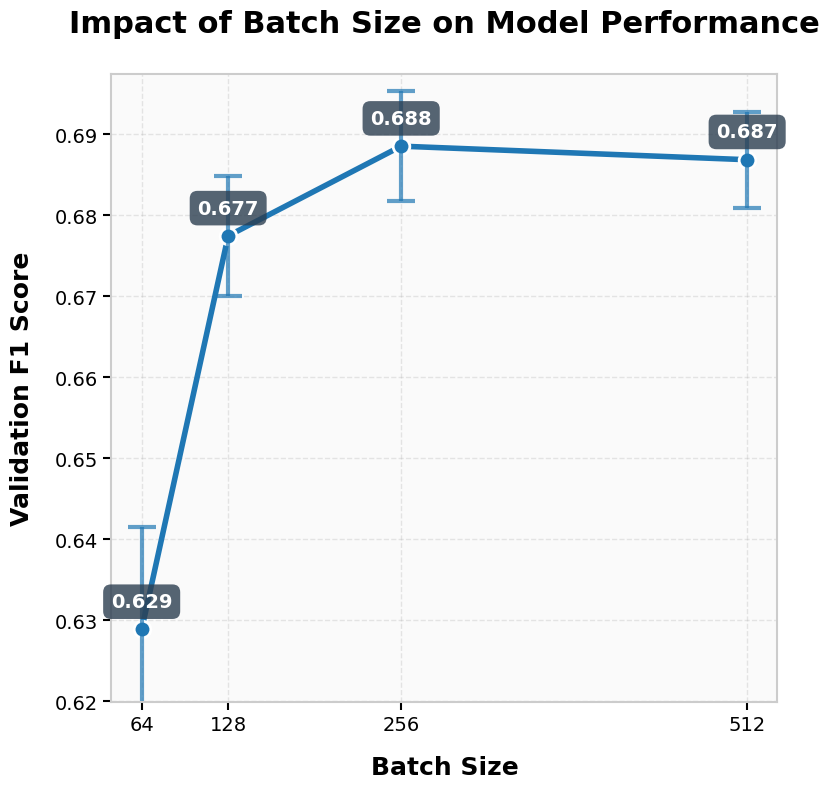

Batch Size vs F1 Score Summary:
 batch_size  f1_mean   f1_std
         64 0.628835 0.012613
        128 0.677421 0.007386
        256 0.688499 0.006752
        512 0.686825 0.005911

Best performing batch size: 256
Highest F1 score: 0.6885 ± 0.0068


<Figure size 640x480 with 0 Axes>

In [11]:
fig, ax = plt.subplots(figsize=(8, 8))

# Create the line plot with improved styling
ax.plot(
    batch_csv_grouped_linear['batch_size'],
    batch_csv_grouped_linear['f1_mean'],
    marker='o',
    markersize=12,
    linewidth=4,
    color='#1f77b4',
    markerfacecolor='#1f77b4',
    markeredgecolor='white',
    markeredgewidth=2
)

# Add error bars with improved styling
ax.errorbar(
    batch_csv_grouped_linear['batch_size'],
    batch_csv_grouped_linear['f1_mean'],
    yerr=batch_csv_grouped_linear['f1_std'],
    fmt='none',
    color='#1f77b4',
    capsize=10,
    capthick=3,
    linewidth=3,
    alpha=0.7
)

# Add value annotations with improved positioning and styling
for _, row in batch_csv_grouped_linear.iterrows():
    ax.annotate(
        f"{row['f1_mean']:.3f}",
        xy=(row['batch_size'], row['f1_mean']),
        textcoords='offset points',
        xytext=(0, 20),
        ha='center',
        va='center',
        color='white',
        fontsize=14,
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.4', 
            facecolor='#2c3e50', 
            edgecolor='none', 
            alpha=0.8
        )
    )

# Improve axes formatting with larger text
ax.set_xlabel('Batch Size', fontsize=18, fontweight='bold', labelpad=15)
ax.set_ylabel('Validation F1 Score', fontsize=18, fontweight='bold', labelpad=15)
ax.set_title('Impact of Batch Size on Model Performance', 
             fontsize=22, fontweight='bold', pad=30)

# Set x-axis to show only actual batch size values (no log scale)
ax.set_xticks(batch_csv_grouped_linear['batch_size'])
ax.set_xticklabels(batch_csv_grouped_linear['batch_size'], fontsize=16)

# Improve y-axis limits with better margins
y_min, y_max = batch_csv_grouped_linear['f1_mean'].min(), batch_csv_grouped_linear['f1_mean'].max()
y_range = y_max - y_min
margin = y_range * 0.15
ax.set_ylim(y_min - margin, y_max + margin)

# Enhanced grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=1)
ax.set_axisbelow(True)

# Add subtle background and spine styling
ax.set_facecolor('#fafafa')
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('#cccccc')

# Improve tick styling with larger text
ax.tick_params(axis='both', which='major', labelsize=14, width=1.5, length=6)

plt.tight_layout()
plt.show()

# Save as high-resolution PDF
plt.savefig('batch_size_performance.pdf', format='pdf', dpi=300, bbox_inches='tight')

# Print summary statistics
print("Batch Size vs F1 Score Summary:")
print(batch_csv_grouped_linear.to_string(index=False))
print(f"\nBest performing batch size: {batch_csv_grouped_linear.loc[batch_csv_grouped_linear['f1_mean'].idxmax(), 'batch_size']}")
print(f"Highest F1 score: {batch_csv_grouped_linear['f1_mean'].max():.4f} ± {batch_csv_grouped_linear.loc[batch_csv_grouped_linear['f1_mean'].idxmax(), 'f1_std']:.4f}")


In [12]:
# Perform pairwise permutation tests between all batch sizes
import numpy as np
from mlxtend.evaluate import permutation_test

# Configuration
N_RESAMPLES = 10000
SIGNIFICANCE_LEVEL = 0.05

# Function to get F1 scores for a specific batch size
def get_f1_scores_for_batch(batch_size_value):
    """Get all F1 scores for a specific batch size"""
    matching_scores = batch_csv[batch_csv['batch_size'] == batch_size_value].sort_values(by='data.split')['val/f1'].values
    return np.array(matching_scores)

# Perform pairwise permutation tests
batch_sizes = sorted(batch_csv['batch_size'].unique())
n_batches = len(batch_sizes)
results = []

print(f"PAIRWISE PERMUTATION TEST ANALYSIS")
print(f"=" * 70)
print(f"Number of batch sizes: {n_batches}")
print(f"Total pairwise comparisons: {n_batches * (n_batches - 1) // 2}")
print(f"Resamples: {N_RESAMPLES:,}")
print(f"Significance level: α = {SIGNIFICANCE_LEVEL}")
print(f"\nStarting analysis...\n")

from time import time
start_time = time()

for i in range(n_batches):
    for j in range(i+1, n_batches):
        batch_i = batch_sizes[i]
        batch_j = batch_sizes[j]
        
        scores_i = get_f1_scores_for_batch(batch_i)
        scores_j = get_f1_scores_for_batch(batch_j)
        
        if len(scores_i) > 1 and len(scores_j) > 1:
            # Perform permutation test
            p_value = permutation_test(
                scores_i, 
                scores_j,
                func='x_mean > y_mean',
                method='approximate',
                num_rounds=N_RESAMPLES,
                paired=True
            )
            
            # Calculate effect size (Cohen's d)
            pooled_std = np.sqrt((np.var(scores_i) + np.var(scores_j)) / 2)
            effect_size = (np.mean(scores_i) - np.mean(scores_j)) / pooled_std if pooled_std > 0 else 0
            
            results.append({
                'batch_size_1': batch_i,
                'batch_size_2': batch_j,
                'mean_f1_1': np.mean(scores_i),
                'mean_f1_2': np.mean(scores_j),
                'std_f1_1': np.std(scores_i),
                'std_f1_2': np.std(scores_j),
                'p_value': p_value,
                'significant': p_value < SIGNIFICANCE_LEVEL,
                'effect_size': effect_size,
                'n_samples_1': len(scores_i),
                'n_samples_2': len(scores_j)
            })

comparison_results = pd.DataFrame(results)
elapsed_time = time() - start_time

print(f"\n✓ ANALYSIS COMPLETE in {elapsed_time:.1f}s")
print(f"=" * 70)
print(f"Speed: {len(comparison_results)/elapsed_time:.1f} comparisons/sec")
print(f"Significant: {comparison_results['significant'].sum()}/{len(comparison_results)} "
      f"({100*comparison_results['significant'].sum()/len(comparison_results):.1f}%)")

print(f"\nTOP SIGNIFICANT DIFFERENCES:")
if comparison_results['significant'].sum() > 0:
    for idx, row in comparison_results[comparison_results['significant']].sort_values('p_value').iterrows():
        print(f"  Batch {row['batch_size_1']} vs {row['batch_size_2']}: p={row['p_value']:.4f}, d={row['effect_size']:.2f}")
else:
    print("  No significant differences found")

print(f"\n")
comparison_results

PAIRWISE PERMUTATION TEST ANALYSIS
Number of batch sizes: 4
Total pairwise comparisons: 6
Resamples: 10,000
Significance level: α = 0.05

Starting analysis...


✓ ANALYSIS COMPLETE in 1.7s
Speed: 3.6 comparisons/sec
Significant: 0/6 (0.0%)

TOP SIGNIFICANT DIFFERENCES:
  No significant differences found



✓ ANALYSIS COMPLETE in 1.7s
Speed: 3.6 comparisons/sec
Significant: 0/6 (0.0%)

TOP SIGNIFICANT DIFFERENCES:
  No significant differences found




,batch_size_1,batch_size_2,mean_f1_1,mean_f1_2,std_f1_1,std_f1_2,p_value,significant,effect_size,n_samples_1,n_samples_2
0,64,128,0.628835,0.677421,0.012359,0.007236,1.000000,False,-4.797772,25,25
1,64,256,0.628835,0.688499,0.012359,0.006616,1.000000,False,-6.019254,25,25
2,64,512,0.628835,0.686825,0.012359,0.005792,1.000000,False,-6.008718,25,25
3,128,256,0.677421,0.688499,0.007236,0.006616,1.000000,False,-1.597937,25,25
4,128,512,0.677421,0.686825,0.007236,0.005792,1.000000,False,-1.434879,25,25
5,256,512,0.688499,0.686825,0.006616,0.005792,0.078592,False,0.269278,25,25


In [13]:
# Export results to CSV
output_path = '/home/fsoto/Documents/LCsSSL/wandb_csv/batch_ablation_results.csv'

# Create summary with mean ± std format
summary_results = []
for batch_size in batch_sizes:
    batch_data = batch_csv_grouped_linear[batch_csv_grouped_linear['batch_size'] == batch_size].iloc[0]
    
    # Count how many batch sizes this one is significantly better than
    sig_better = comparison_results[
        (comparison_results['batch_size_1'] == batch_size) &
        (comparison_results['significant'] == True) &
        (comparison_results['effect_size'] > 0)
    ]
    
    summary_results.append({
        'Batch_Size': batch_size,
        'F1_Mean': batch_data['f1_mean'],
        'F1_Std': batch_data['f1_std'],
        'Count': len(batch_csv[batch_csv['batch_size'] == batch_size]),
        'Num_Significantly_Better_Than': len(sig_better)
    })

summary_df = pd.DataFrame(summary_results)
summary_df = summary_df.sort_values(by='F1_Mean', ascending=False)
summary_df.to_csv(output_path, index=False, float_format='%.6f')

print(f"✓ Summary results saved to: {output_path}")
print(f"  Rows: {len(summary_df)}")
print(f"\nSummary:")
print(summary_df.to_string(index=False))

# Also save detailed pairwise comparisons
detailed_output_path = '/home/fsoto/Documents/LCsSSL/wandb_csv/batch_ablation_pairwise.csv'
comparison_results.to_csv(detailed_output_path, index=False, float_format='%.6f')
print(f"\n✓ Detailed pairwise comparisons saved to: {detailed_output_path}")

✓ Summary results saved to: /home/fsoto/Documents/LCsSSL/wandb_csv/batch_ablation_results.csv
  Rows: 4

Summary:
 Batch_Size  F1_Mean   F1_Std  Count  Num_Significantly_Better_Than
        256 0.688499 0.006752     25                              0
        512 0.686825 0.005911     25                              0
        128 0.677421 0.007386     25                              0
         64 0.628835 0.012613     25                              0

✓ Detailed pairwise comparisons saved to: /home/fsoto/Documents/LCsSSL/wandb_csv/batch_ablation_pairwise.csv


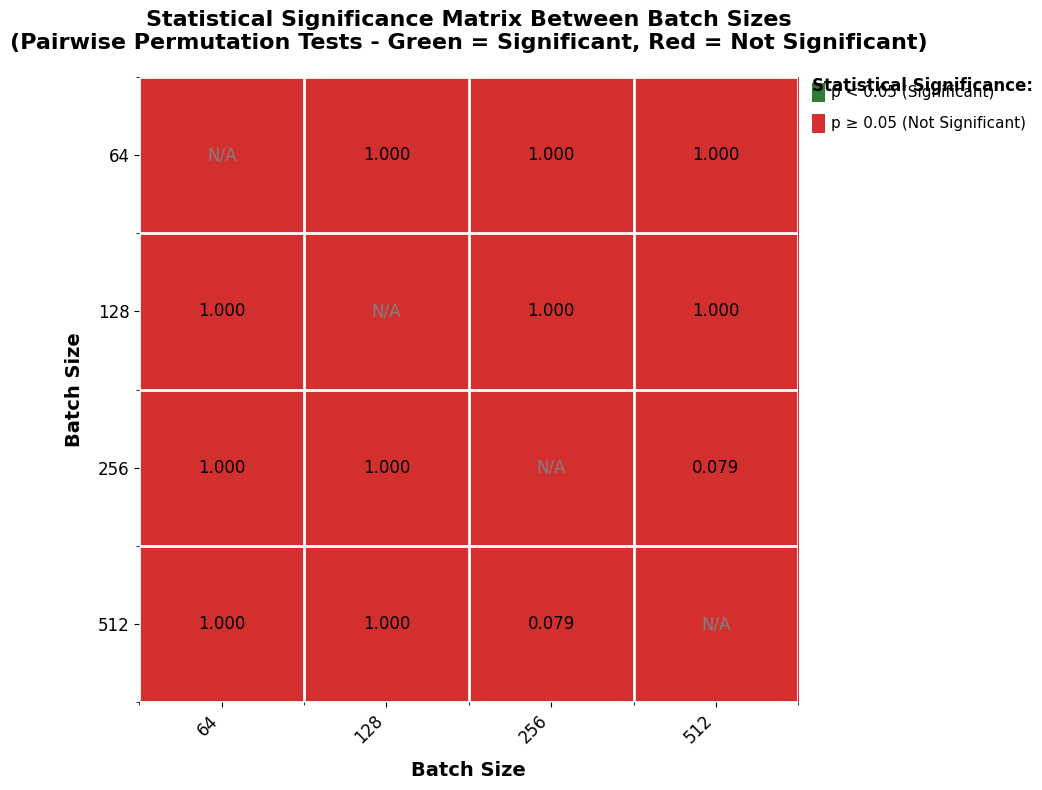


✓ Significance matrix plot saved to: batch_significance_matrix.png


In [14]:
# Create significance matrix (confusion matrix style)
import matplotlib.pyplot as plt
import seaborn as sns

# Create p-value matrix
p_value_matrix = np.ones((n_batches, n_batches))

for _, row in comparison_results.iterrows():
    i = batch_sizes.index(row['batch_size_1'])
    j = batch_sizes.index(row['batch_size_2'])
    p_value_matrix[i, j] = row['p_value']
    p_value_matrix[j, i] = row['p_value']  # Make symmetric

# Create the heatmap
fig, ax = plt.subplots(1, 1, figsize=(10, 8), facecolor='white')

# Create binary significance matrix for visualization
significance_matrix = (p_value_matrix < SIGNIFICANCE_LEVEL).astype(int)

# Use a custom colormap: red for not significant, green for significant
colors = ['#D32F2F', '#2E7D32']  # Red, Green
cmap = plt.matplotlib.colors.ListedColormap(colors)

# Plot the heatmap
im = ax.imshow(significance_matrix, cmap=cmap, aspect='auto', vmin=0, vmax=1)

# Add p-value annotations
for i in range(n_batches):
    for j in range(n_batches):
        if i != j:
            # Choose text color based on background
            text_color = 'white' if significance_matrix[i, j] == 1 else 'black'
            ax.text(j, i, f'{p_value_matrix[i, j]:.3f}',
                   ha='center', va='center',
                   fontsize=12,
                   color=text_color,
                   fontweight='500')
        else:
            # Diagonal - mark as N/A
            ax.text(j, i, 'N/A',
                   ha='center', va='center',
                   fontsize=12,
                   color='gray',
                   fontweight='500')

# Set ticks and labels
batch_labels = [str(bs) for bs in batch_sizes]
ax.set_xticks(range(n_batches))
ax.set_yticks(range(n_batches))
ax.set_xticklabels(batch_labels, rotation=45, ha='right', fontsize=12, fontweight='500')
ax.set_yticklabels(batch_labels, fontsize=12, fontweight='500')

# Labels and title
ax.set_xlabel('Batch Size', fontsize=14, fontweight='600', labelpad=10)
ax.set_ylabel('Batch Size', fontsize=14, fontweight='600', labelpad=10)
ax.set_title('Statistical Significance Matrix Between Batch Sizes\n(Pairwise Permutation Tests - Green = Significant, Red = Not Significant)',
             fontsize=16, pad=20, fontweight='bold')

# Add grid
ax.set_xticks(np.arange(-0.5, n_batches, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_batches, 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Add colorbar legend
from matplotlib.patches import Rectangle
legend_labels = [
    f'p < {SIGNIFICANCE_LEVEL} (Significant)',
    f'p ≥ {SIGNIFICANCE_LEVEL} (Not Significant)'
]
legend_colors = ['#2E7D32', '#D32F2F']

ax.text(1.02, 1.0, "Statistical Significance:", transform=ax.transAxes,
        fontsize=12, fontweight='bold', va='top', ha='left')

for i, (color, label) in enumerate(zip(legend_colors, legend_labels)):
    y_pos = 0.96 - i * 0.05
    rect = Rectangle((1.02, y_pos), 0.02, 0.03,
                     facecolor=color, transform=ax.transAxes, clip_on=False)
    ax.add_patch(rect)
    ax.text(1.05, y_pos + 0.015, label,
            transform=ax.transAxes, fontsize=11, va='center', ha='left',
            fontweight='500')

plt.tight_layout()
plt.savefig('/home/fsoto/Documents/LCsSSL/wandb_csv/batch_significance_matrix.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Significance matrix plot saved to: batch_significance_matrix.png")